In [4]:
import os 
import json 
from collections import Counter
from typing import Dict, List, Tuple, Literal 

import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')


import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from utils.analysis import *

In [5]:
RESULTS_PATH = "../results"

In [6]:
# build analysis dataframe 
# Task 1 (direct prompting)
task1_q, task1_s = load_results(RESULTS_PATH, experiment="prompting")
task1_df = pd.concat([task1_q, task1_s], ignore_index=True)[["nodes", "model", "data", "task", "correct"]].copy()
task1_df["correct"] = task1_df["correct"].astype(int)

# Task 2 (probability discrimination)
task2_q, task2_s = load_results(RESULTS_PATH, experiment="probabilities")
task2_df = pd.concat([task2_q, task2_s], ignore_index=True)[["nodes", "model", "data", "task", "sents_logprob", "swapped_logprob"]].copy()
task2_df["prob_diff"] = task2_df["sents_logprob"] - task2_df["swapped_logprob"]

# Merge Task 1 and Task 2 at item level
analysis_df = task1_df.merge(
    task2_df[["nodes", "model", "data", "task", "prob_diff"]],
    on=["nodes", "model", "data", "task"],
    how="inner"
).dropna()

Rows used: 36240
Accuracy: 0.7336
ROC-AUC: 0.778

Effect of prob_diff on correctness (controlling for model, data, task):
Coefficient (log-odds): 0.0638
Odds ratio per +1 unit prob_diff: 1.0658
Interpretation: higher probability difference is associated with higher chance of Task 1 correctness.


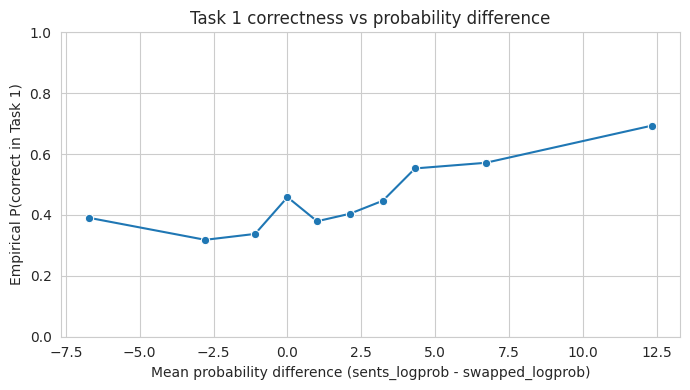

In [7]:
X = analysis_df[["prob_diff", "model", "data", "task"]]
y = analysis_df["correct"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), ["model", "data", "task"]),
        ("num", "passthrough", ["prob_diff"]),
    ]
)

clf = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("logreg", LogisticRegression(max_iter=3000)),
    ]
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_score = clf.predict_proba(X_test)[:, 1]

print("Rows used:", len(analysis_df))
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_score), 4))

feature_names = clf.named_steps["preprocess"].get_feature_names_out()
coefs = pd.Series(clf.named_steps["logreg"].coef_[0], index=feature_names)
prob_diff_coef = coefs["num__prob_diff"]
prob_diff_odds_ratio = float(np.exp(prob_diff_coef))

print("\nEffect of prob_diff on correctness (controlling for model, data, task):")
print("Coefficient (log-odds):", round(prob_diff_coef, 4))
print("Odds ratio per +1 unit prob_diff:", round(prob_diff_odds_ratio, 4))

if prob_diff_coef > 0:
    print("Interpretation: higher probability difference is associated with higher chance of Task 1 correctness.")
else:
    print("Interpretation: higher probability difference is associated with lower chance of Task 1 correctness.")

# Optional visualization: empirical correctness vs prob_diff bins
plot_df = analysis_df.copy()
plot_df["prob_bin"] = pd.qcut(plot_df["prob_diff"], q=10, duplicates="drop")
bin_summary = plot_df.groupby("prob_bin", observed=True).agg(
    mean_prob_diff=("prob_diff", "mean"),
    p_correct=("correct", "mean")
).reset_index(drop=True)

plt.figure(figsize=(7, 4))
sns.lineplot(data=bin_summary, x="mean_prob_diff", y="p_correct", marker="o")
plt.xlabel("Mean probability difference (sents_logprob - swapped_logprob)")
plt.ylabel("Empirical P(correct in Task 1)")
plt.title("Task 1 correctness vs probability difference")
plt.ylim(0, 1)
plt.tight_layout()

## Stats Model

In [8]:
import statsmodels.formula.api as smf

# Statsmodels logistic regression with p-values and confidence intervals
sm_df = analysis_df.copy()
sm_df["correct"] = sm_df["correct"].astype(int)

sm_model = smf.logit(
    "correct ~ prob_diff + C(model) + C(data) + C(task)",
    data=sm_df
).fit(disp=False)

print(sm_model.summary())

coef = sm_model.params["prob_diff"]
pvalue = sm_model.pvalues["prob_diff"]
ci_low, ci_high = sm_model.conf_int().loc["prob_diff"]

print("\nInference for prob_diff:")
print("Coefficient (log-odds):", round(coef, 4))
print("Odds ratio:", round(float(np.exp(coef)), 4))
print("95% CI for coefficient:", f"[{ci_low:.4f}, {ci_high:.4f}]")
print("95% CI for odds ratio:", f"[{np.exp(ci_low):.4f}, {np.exp(ci_high):.4f}]")
print("p-value:", f"{pvalue:.4g}")

                           Logit Regression Results                           
Dep. Variable:                correct   No. Observations:                36240
Model:                          Logit   Df Residuals:                    36230
Method:                           MLE   Df Model:                            9
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.1770
Time:                        13:27:35   Log-Likelihood:                -20527.
converged:                       True   LL-Null:                       -24943.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -1.6514      0.037    -44.071      0.000      -1.725      -1.578
C(model)[T.gemma-3-4b-it]       1.2992      0.040     32.265      0.000       1.

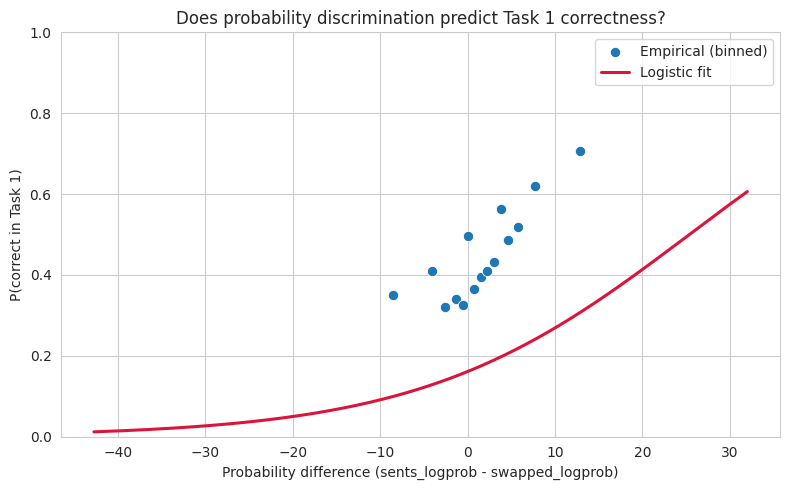

In [9]:
# Plot: empirical correctness and logistic fit vs probability difference
plot_df = analysis_df.copy()
plot_df["prob_bin"] = pd.qcut(plot_df["prob_diff"], q=15, duplicates="drop")
empirical = plot_df.groupby("prob_bin", observed=True).agg(
    mean_prob_diff=("prob_diff", "mean"),
    p_correct=("correct", "mean")
).reset_index(drop=True)

# Keep categorical controls fixed at their most frequent level
ref_model = sm_df["model"].mode()[0]
ref_data = sm_df["data"].mode()[0]
ref_task = sm_df["task"].mode()[0]

x_grid = np.linspace(sm_df["prob_diff"].min(), sm_df["prob_diff"].max(), 300)
pred_df = pd.DataFrame({
    "prob_diff": x_grid,
    "model": ref_model,
    "data": ref_data,
    "task": ref_task,
})
pred_p = sm_model.predict(pred_df)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=empirical, x="mean_prob_diff", y="p_correct", s=55, label="Empirical (binned)") # Probability difference (binned)
plt.plot(x_grid, pred_p, color="crimson", linewidth=2.2, label="Logistic fit")
plt.ylim(0, 1)
plt.xlabel("Probability difference (sents_logprob - swapped_logprob)")
plt.ylabel("P(correct in Task 1)")
plt.title("Does probability discrimination predict Task 1 correctness?")
plt.legend()
plt.tight_layout()

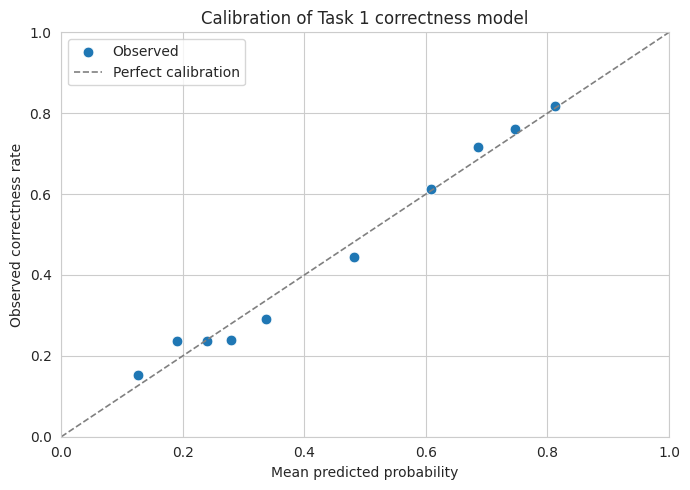

In [10]:
# Calibration plot for the size-controlled logistic model
cal_df_nosize = sm_df.copy()
cal_df_nosize["pred_prob"] = sm_model.predict(cal_df_nosize)
cal_df_nosize["prob_bin"] = pd.qcut(cal_df_nosize["pred_prob"], q=10, duplicates="drop")

calibration = cal_df_nosize.groupby("prob_bin", observed=True).agg(
    mean_pred_prob=("pred_prob", "mean"),
    obs_rate=("correct", "mean")
).reset_index(drop=True)

plt.figure(figsize=(7, 5))
sns.scatterplot(data=calibration, x="mean_pred_prob", y="obs_rate", s=60, label="Observed")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1.2, label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed correctness rate")
plt.title("Calibration of Task 1 correctness model")
plt.ylim(0, 1)
plt.xlim(0, 1)
plt.legend()
plt.tight_layout()

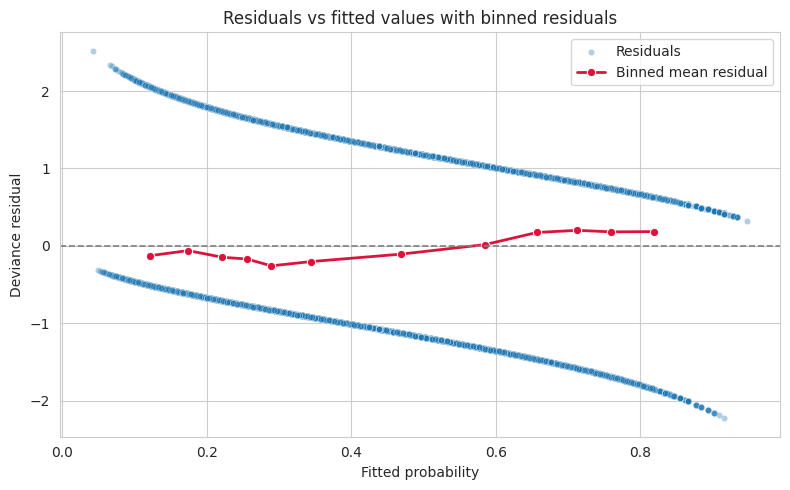

In [11]:
# Residuals vs fitted probabilities with binned residual means
fitted_prob = sm_model.predict(sm_df)
observed = sm_df["correct"].astype(float).to_numpy()

# Manual deviance residuals for a binary logistic model
eps = 1e-12
fitted_prob = np.clip(np.asarray(fitted_prob), eps, 1 - eps)
deviance_component = np.where(observed == 1, -2 * np.log(fitted_prob), -2 * np.log(1 - fitted_prob))
deviance_resid = np.sign(observed - fitted_prob) * np.sqrt(deviance_component)

resid_df = pd.DataFrame({
    "fitted_prob": fitted_prob,
    "deviance_resid": deviance_resid,
})

# Bin fitted values into quantiles and compute mean residual per bin
resid_df["fitted_bin"] = pd.qcut(resid_df["fitted_prob"], q=12, duplicates="drop")
binned_resid = resid_df.groupby("fitted_bin", observed=True).agg(
    mean_fitted=("fitted_prob", "mean"),
    mean_resid=("deviance_resid", "mean")
).reset_index(drop=True)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=resid_df, x="fitted_prob", y="deviance_resid", s=20, alpha=0.35, label="Residuals")
sns.lineplot(
    data=binned_resid,
    x="mean_fitted",
    y="mean_resid",
    marker="o",
    linewidth=2,
    color="crimson",
    label="Binned mean residual",
)
plt.axhline(0, color="gray", linestyle="--", linewidth=1.2)
plt.xlabel("Fitted probability")
plt.ylabel("Deviance residual")
plt.title("Residuals vs fitted values with binned residuals")
plt.legend()
plt.tight_layout()

## StatsModel 2

size as a predictor


In [12]:
# Alternative model: control for model size (in billions)
sm_df_size = analysis_df.copy()
sm_df_size["correct"] = sm_df_size["correct"].astype(int)

# Extract size from model name (e.g., 1b, 3b, 8b -> 1.0, 3.0, 8.0)
sm_df_size["model_size_b"] = (
    sm_df_size["model"]
    .str.extract(r"(\d+(?:\.\d+)?)b", expand=False)
    .astype(float)
)

# Control model family separately to avoid collinearity with exact model dummies
sm_df_size["model_family"] = sm_df_size["model"].str.split("-").str[0]

sm_model_size = smf.logit(
    "correct ~ prob_diff + model_size_b + C(model_family) + C(data) + C(task)",
    data=sm_df_size
).fit(disp=False)

print(sm_model_size.summary())

for var in ["prob_diff", "model_size_b"]:
    coef = sm_model_size.params[var]
    pvalue = sm_model_size.pvalues[var]
    ci_low, ci_high = sm_model_size.conf_int().loc[var]
    print(f"\nInference for {var}:")
    print("Coefficient (log-odds):", round(coef, 4))
    print("Odds ratio:", round(float(np.exp(coef)), 4))
    print("95% CI for coefficient:", f"[{ci_low:.4f}, {ci_high:.4f}]")
    print("95% CI for odds ratio:", f"[{np.exp(ci_low):.4f}, {np.exp(ci_high):.4f}]")
    print("p-value:", f"{pvalue:.4g}")

                           Logit Regression Results                           
Dep. Variable:                correct   No. Observations:                36240
Model:                          Logit   Df Residuals:                    36233
Method:                           MLE   Df Model:                            6
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.1686
Time:                        13:30:27   Log-Likelihood:                -20737.
converged:                       True   LL-Null:                       -24943.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   -1.9036      0.034    -56.357      0.000      -1.970      -1.837
C(model_family)[T.llama]    -0.6410      0.024    -26.665      0.000      -0.688      -0.

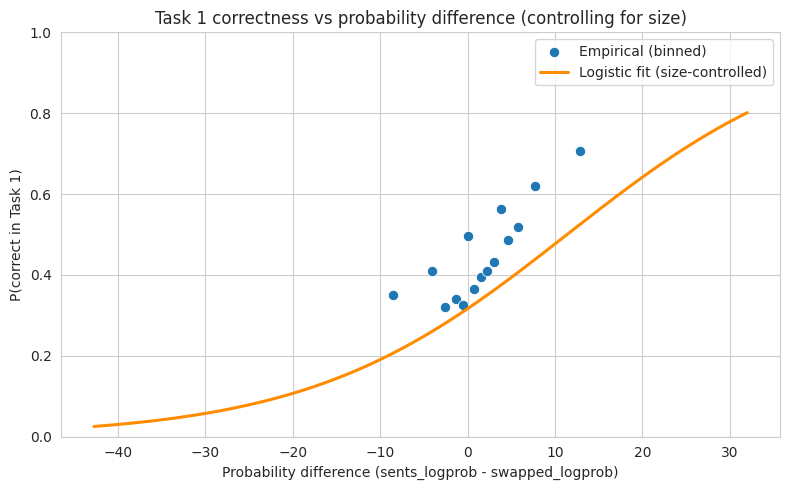

In [13]:
# Plot: empirical correctness and logistic fit vs probability difference (size-controlled model)
plot_df_size = sm_df_size.copy()
plot_df_size["prob_bin"] = pd.qcut(plot_df_size["prob_diff"], q=15, duplicates="drop")
empirical_size = plot_df_size.groupby("prob_bin", observed=True).agg(
    mean_prob_diff=("prob_diff", "mean"),
    p_correct=("correct", "mean")
).reset_index(drop=True)

# Keep controls fixed at their most frequent level
ref_family = sm_df_size["model_family"].mode()[0]
ref_data = sm_df_size["data"].mode()[0]
ref_task = sm_df_size["task"].mode()[0]
ref_size = float(sm_df_size["model_size_b"].median())

x_grid = np.linspace(sm_df_size["prob_diff"].min(), sm_df_size["prob_diff"].max(), 300)
pred_df_size = pd.DataFrame({
    "prob_diff": x_grid,
    "model_size_b": ref_size,
    "model_family": ref_family,
    "data": ref_data,
    "task": ref_task,
})
pred_p_size = sm_model_size.predict(pred_df_size)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=empirical_size, x="mean_prob_diff", y="p_correct", s=55, label="Empirical (binned)")
plt.plot(x_grid, pred_p_size, color="darkorange", linewidth=2.2, label="Logistic fit (size-controlled)")
plt.ylim(0, 1)
plt.xlabel("Probability difference (sents_logprob - swapped_logprob)")
plt.ylabel("P(correct in Task 1)")
plt.title("Task 1 correctness vs probability difference (controlling for size)")
plt.legend()
plt.tight_layout()

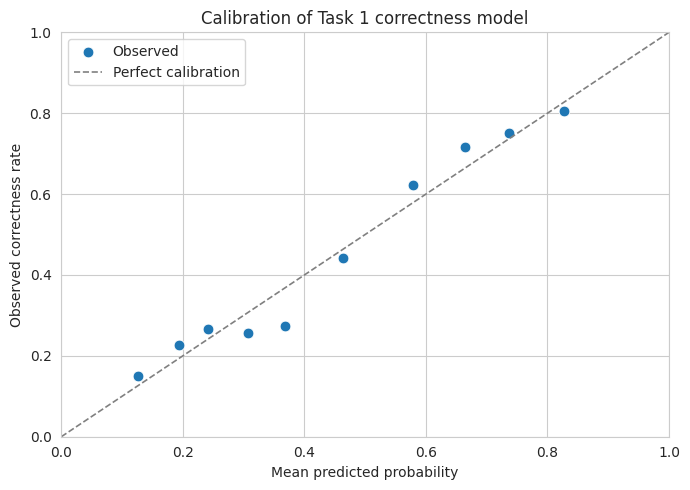

In [14]:
# Calibration plot for the size-controlled logistic model
cal_df = sm_df_size.copy()
cal_df["pred_prob"] = sm_model_size.predict(cal_df)
cal_df["prob_bin"] = pd.qcut(cal_df["pred_prob"], q=10, duplicates="drop")

calibration = cal_df.groupby("prob_bin", observed=True).agg(
    mean_pred_prob=("pred_prob", "mean"),
    obs_rate=("correct", "mean")
).reset_index(drop=True)

plt.figure(figsize=(7, 5))
sns.scatterplot(data=calibration, x="mean_pred_prob", y="obs_rate", s=60, label="Observed")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1.2, label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed correctness rate")
plt.title("Calibration of Task 1 correctness model")
plt.ylim(0, 1)
plt.xlim(0, 1)
plt.legend()
plt.tight_layout()

# Quadratic model

In [15]:
# Test nonlinearity: quadratic model
sm_df_quad = sm_df_size.copy()
sm_df_quad["prob_diff_sq"] = sm_df_quad["prob_diff"] ** 2

sm_model_quad = smf.logit(
    "correct ~ prob_diff + prob_diff_sq + model_size_b + C(model_family) + C(data) + C(task)",
    data=sm_df_quad
).fit(disp=False)

print("QUADRATIC MODEL (with prob_diff^2):")
print(sm_model_quad.summary())

print("\n" + "="*60)
print("MODEL COMPARISON:")
print("="*60)
print(f"Linear model AIC: {sm_model_size.aic:.2f}")
print(f"Quadratic model AIC: {sm_model_quad.aic:.2f}")
print(f"AIC improvement: {sm_model_size.aic - sm_model_quad.aic:.2f} (negative = better)")
print()
print("Quadratic term (prob_diff_sq):")
coef_sq = sm_model_quad.params["prob_diff_sq"]
pval_sq = sm_model_quad.pvalues["prob_diff_sq"]
print(f"  Coefficient: {coef_sq:.4f}")
print(f"  p-value: {pval_sq:.4g}")
if pval_sq < 0.05:
    print("  → Significant nonlinear effect detected!")
else:
    print("  → Not significant; linear model may be adequate.")


QUADRATIC MODEL (with prob_diff^2):
                           Logit Regression Results                           
Dep. Variable:                correct   No. Observations:                36240
Model:                          Logit   Df Residuals:                    36232
Method:                           MLE   Df Model:                            7
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.1686
Time:                        13:31:11   Log-Likelihood:                -20737.
converged:                       True   LL-Null:                       -24943.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   -1.8993      0.035    -55.028      0.000      -1.967      -1.832
C(model_family)[T.llama]    -0.6453      0.025    -25

Text(0.5, 1.02, 'Residuals: Do you still see the curve in the quadratic model?')

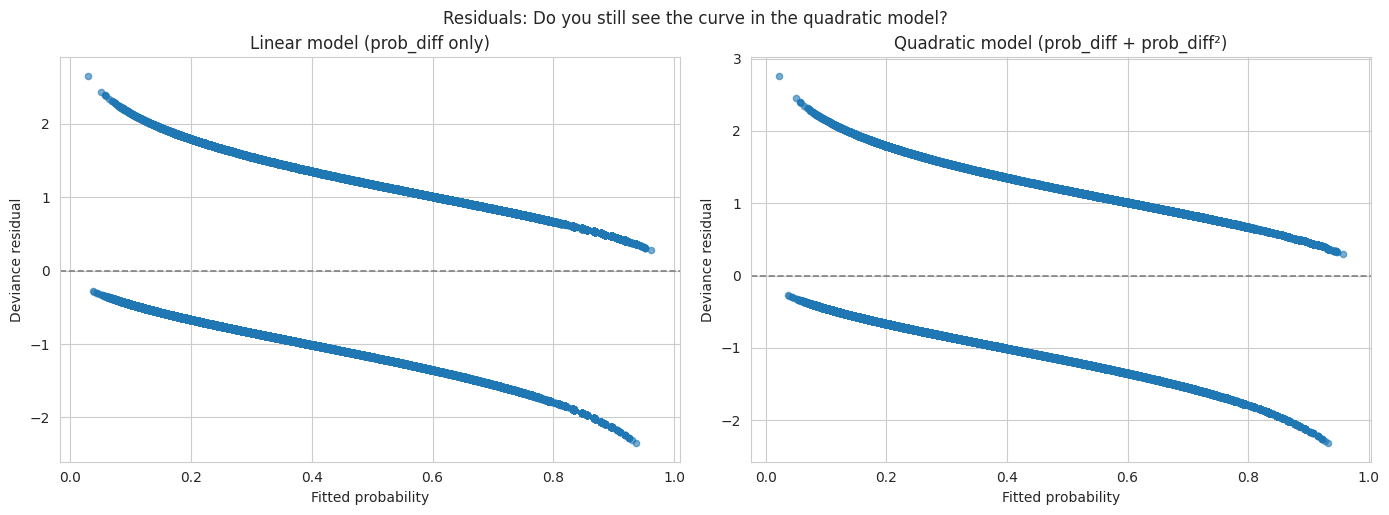

In [16]:
# Compare residuals: linear vs quadratic
fitted_linear = sm_model_size.predict(sm_df_size)
fitted_quad = sm_model_quad.predict(sm_df_quad)
observed = sm_df_size["correct"].astype(float).to_numpy()

eps = 1e-12

# Linear residuals
fitted_linear_clipped = np.clip(np.asarray(fitted_linear), eps, 1 - eps)
deviance_linear = np.where(observed == 1, -2 * np.log(fitted_linear_clipped), -2 * np.log(1 - fitted_linear_clipped))
resid_linear = np.sign(observed - fitted_linear_clipped) * np.sqrt(deviance_linear)

# Quadratic residuals
fitted_quad_clipped = np.clip(np.asarray(fitted_quad), eps, 1 - eps)
deviance_quad = np.where(observed == 1, -2 * np.log(fitted_quad_clipped), -2 * np.log(1 - fitted_quad_clipped))
resid_quad = np.sign(observed - fitted_quad_clipped) * np.sqrt(deviance_quad)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear
axes[0].scatter(fitted_linear_clipped, resid_linear, s=20, alpha=0.6)
axes[0].axhline(0, color="gray", linestyle="--", linewidth=1.2)
axes[0].set_xlabel("Fitted probability")
axes[0].set_ylabel("Deviance residual")
axes[0].set_title("Linear model (prob_diff only)")

# Quadratic
axes[1].scatter(fitted_quad_clipped, resid_quad, s=20, alpha=0.6)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=1.2)
axes[1].set_xlabel("Fitted probability")
axes[1].set_ylabel("Deviance residual")
axes[1].set_title("Quadratic model (prob_diff + prob_diff²)")

plt.tight_layout()
plt.suptitle("Residuals: Do you still see the curve in the quadratic model?", y=1.02)
